In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import yaml

CONFIG_PATH = "/content/config.yaml"

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

DRIVE_ROOT = f"/content/drive/MyDrive/{config['project_name']}"
RAW_DATA_PATH = os.path.join(DRIVE_ROOT, config['paths']['raw_data'])

print(f"프로젝트: {config['project_name']}")
print(f"Raw 데이터 경로: {RAW_DATA_PATH}")

프로젝트: EcoTracing
Raw 데이터 경로: /content/drive/MyDrive/EcoTracing/raw


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import json

# 다크모드 스타일 설정
plt.style.use('dark_background')
sns.set_palette("bright")

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [5]:
def load_json_gz(file_path, n_rows=None):
    data = []
    with gzip.open(file_path, 'rt') as f:
        for i, line in enumerate(f):
            if n_rows and i >= n_rows:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

In [6]:
# file_path  = os.path.join(RAW_DATA_PATH, "instance_usage-000000000000.json.gz")
# # 전체 로드 (또는 샘플: n_rows=10000)
# df = load_json_gz(file_path )

# print(f"Shape: {df.shape}")
# print(f"\n컬럼: {df.columns.tolist()}")

file_path  = os.path.join(RAW_DATA_PATH, "instance_usage-000000000000.json.gz")
data = []
with gzip.open(file_path, 'rt') as f:
    for i, line in enumerate(f):
        if i >= 10000:  # 10,000개만 로드
            break
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(f"Shape: {df.shape}")
print(f"컬럼: {df.columns.tolist()}")


Shape: (10000, 18)
컬럼: ['start_time', 'end_time', 'collection_id', 'instance_index', 'machine_id', 'alloc_collection_id', 'alloc_instance_index', 'collection_type', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution']


In [7]:
print("=== 첫 번째 행 상세 ===")
for col in df.columns:
    print(f"{col}: {df[col].iloc[0]}")
    
print("=== 데이터 타입 ===")
print(df.dtypes)

print("\n=== 결측치 ===")
print(df.isnull().sum())

print("\n=== 기초 통계 ===")
df.describe()

# 샘플 확인
df.head(10)

=== 첫 번째 행 상세 ===
start_time: 1838400000000
end_time: 1838700000000
collection_id: 330587238433
instance_index: 111
machine_id: 23624491139
alloc_collection_id: 330587160469
alloc_instance_index: 111
collection_type: 0
average_usage: {'cpus': 0.008392333984375, 'memory': 0.0094757080078125}
maximum_usage: {'cpus': 0.04791259765625, 'memory': 0.019378662109375}
random_sample_usage: {'cpus': 0.016632080078125}
assigned_memory: 0
page_cache_memory: 0.0032196044921875
cycles_per_instruction: 0.8992443084716797
memory_accesses_per_instruction: 0.00151212012860924
sample_rate: 0.996666669845581
cpu_usage_distribution: [0.0004711151123046875, 0.0006809234619140625, 0.0007581710815429688, 0.00083160400390625, 0.0009622573852539062, 0.0084381103515625, 0.008880615234375, 0.0133056640625, 0.016448974609375, 0.021942138671875, 0.04779052734375]
tail_cpu_usage_distribution: [0.022308349609375, 0.023681640625, 0.024200439453125, 0.025360107421875, 0.02606201171875, 0.02685546875, 0.028411865234375,

,start_time,end_time,collection_id,instance_index,machine_id,alloc_collection_id,alloc_instance_index,collection_type,average_usage,maximum_usage,random_sample_usage,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution
0,1838400000000,1838700000000,330587238433,111,23624491139,330587160469,111,0,"{'cpus': 0.008392333984375, 'memory': 0.009475...","{'cpus': 0.04791259765625, 'memory': 0.0193786...",{'cpus': 0.016632080078125},0,0.003220,0.899244,0.001512,0.996667,"[0.0004711151123046875, 0.0006809234619140625,...","[0.022308349609375, 0.023681640625, 0.02420043..."
1,1839000000000,1839300000000,330587238433,111,23624491139,330587160469,111,0,"{'cpus': 0.027099609375, 'memory': 0.027618408...","{'cpus': 0.0736083984375, 'memory': 0.02795410...",{'cpus': 0.019683837890625},0,0.001808,0.899244,0.001512,1.000000,"[0.0088043212890625, 0.016357421875, 0.0186157...","[0.04290771484375, 0.0440673828125, 0.04663085..."
2,942000000000,942300000000,330587238433,111,23624491139,330587160469,111,0,"{'cpus': 0.024932861328125, 'memory': 0.012466...","{'cpus': 0.11767578125, 'memory': 0.019287109375}",{'cpus': 0.00860595703125},0,0.002392,1.028699,0.003364,1.000000,"[5.435943603515625e-05, 0.00020122528076171875...","[0.052001953125, 0.052490234375, 0.052734375, ..."
3,941700000000,942000000000,330587238433,111,23624491139,330587160469,111,0,"{'cpus': 0.019134521484375, 'memory': 0.010955...","{'cpus': 0.1209716796875, 'memory': 0.01931762...",{'cpus': 0.00020503997802734375},0,0.001934,1.075302,0.003459,1.000000,"[4.482269287109375e-05, 7.915496826171875e-05,...","[0.04559326171875, 0.04620361328125, 0.0468139..."
4,1837800000000,1838100000000,330587238433,111,23624491139,330587160469,111,0,"{'cpus': 0.001163482666015625, 'memory': 0.000...","{'cpus': 0.0110626220703125, 'memory': 0.00195...",{'cpus': 0.0009307861328125},0,0.000813,0.899244,0.001512,1.000000,"[8.7738037109375e-05, 0.00010204315185546875, ...","[0.00592803955078125, 0.00677490234375, 0.0073..."
5,2530500000000,2530800000000,330587238433,2151,21242629,330587160469,2151,0,"{'cpus': 0.013519287109375, 'memory': 0.006713...","{'cpus': 0.0777587890625, 'memory': 0.01980590...",{'cpus': 0.0146331787109375},0,0.000768,0.869141,0.001528,1.000000,"[5.626678466796875e-05, 6.4849853515625e-05, 7...","[0.04534912109375, 0.04571533203125, 0.0467529..."
6,2531400000000,2531700000000,330587238433,2151,21242629,330587160469,2151,0,"{'cpus': 0.0011692047119140625, 'memory': 0.00...","{'cpus': 0.03985595703125, 'memory': 0.0081939...",{'cpus': 6.771087646484375e-05},0,0.000952,0.963354,0.001443,1.000000,"[5.340576171875e-05, 5.817413330078125e-05, 6....","[0.000659942626953125, 0.000858306884765625, 0..."
7,2531100000000,2531400000000,330587238433,2151,21242629,330587160469,2151,0,"{'cpus': 0.03564453125, 'memory': 0.0132446289...","{'cpus': 0.0931396484375, 'memory': 0.01440429...",{'cpus': 0.03863525390625},0,0.002186,0.935524,0.001468,1.000000,"[0.00037479400634765625, 0.000957489013671875,...","[0.04986572265625, 0.05023193359375, 0.0507202..."
8,2531700000000,2531836000000,330587238433,2151,21242629,330587160469,2151,0,"{'cpus': 0.00021457672119140625, 'memory': 0.0...","{'cpus': 0.0063629150390625, 'memory': 0.00087...",{'cpus': 8.7738037109375e-05},0,0.000407,0.963354,0.001443,1.000000,"[5.340576171875e-05, 5.817413330078125e-05, 6....","[0.00018405914306640625, 0.0001955032348632812..."
9,2531836000000,2531848000000,330587238433,2151,21242629,330587160469,2151,0,"{'cpus': 0.0012378692626953125, 'memory': 0.00...","{'cpus': 0.0054779052734375, 'memory': 0.00082...",{'cpus': 0.0001049041748046875},0,0.000407,0.963354,0.001443,1.000000,"[2.47955322265625e-05, 9.72747802734375e-05, 0...","[0.003650665283203125, 0.00547027587890625, 0...."


In [8]:
# # CPU 사용률 분포
# if 'average_usage' in df.columns:
#     cpu_col = 'average_usage'
# elif 'avg_cpu' in df.columns:
#     cpu_col = 'avg_cpu'
# else:
#     cpu_col = None
#     print("CPU 컬럼 확인 필요:", df.columns.tolist())

# if cpu_col:
#     plt.figure(figsize=(12, 6))

#     # CPU 사용률이 dict인 경우 처리
#     if isinstance(df[cpu_col].iloc[0], dict):
#         cpu_values = df[cpu_col].apply(lambda x: x.get('cpus', 0) if isinstance(x, dict) else 0)
#     else:
#         cpu_values = df[cpu_col]

#     plt.hist(cpu_values, bins=50, color='cyan', edgecolor='white', alpha=0.7)
#     plt.title('CPU 사용률 분포', fontsize=14, color='white')
#     plt.xlabel('CPU Usage', fontsize=12, color='white')
#     plt.ylabel('Count', fontsize=12, color='white')
#     plt.tight_layout()
#     plt.show()

# ===========================================
# CPU/메모리 컬럼 추출 (최적화)
# ===========================================
# average_usage가 dict인 경우 풀어서 새 컬럼 생성
if 'average_usage' in df.columns:
    # 리스트 컴프리헨션 사용 (apply보다 빠름)
    df['cpu'] = [x.get('cpus', 0) if isinstance(x, dict) else 0 for x in df['average_usage']]
    df['memory'] = [x.get('memory', 0) if isinstance(x, dict) else 0 for x in df['average_usage']]
    print("CPU/메모리 컬럼 추출 완료!")
    print(f"CPU 평균: {df['cpu'].mean():.4f}")
    print(f"메모리 평균: {df['memory'].mean():.4f}")


CPU/메모리 컬럼 추출 완료!
CPU 평균: 0.0193
메모리 평균: 0.0128


In [9]:
print("=== 기초 통계 ===")
print(df[['cpu', 'memory']].describe())

=== 기초 통계 ===
                cpu        memory
count  10000.000000  10000.000000
mean       0.019280      0.012779
std        0.012822      0.007207
min        0.000018      0.000004
25%        0.008636      0.007118
50%        0.019592      0.013550
75%        0.028961      0.019073
max        0.085938      0.039307


/tmp/ipython-input-2647852851.py:7: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2647852851.py:7: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2647852851.py:7: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2647852851.py:7: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2647852851.py:7: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 5

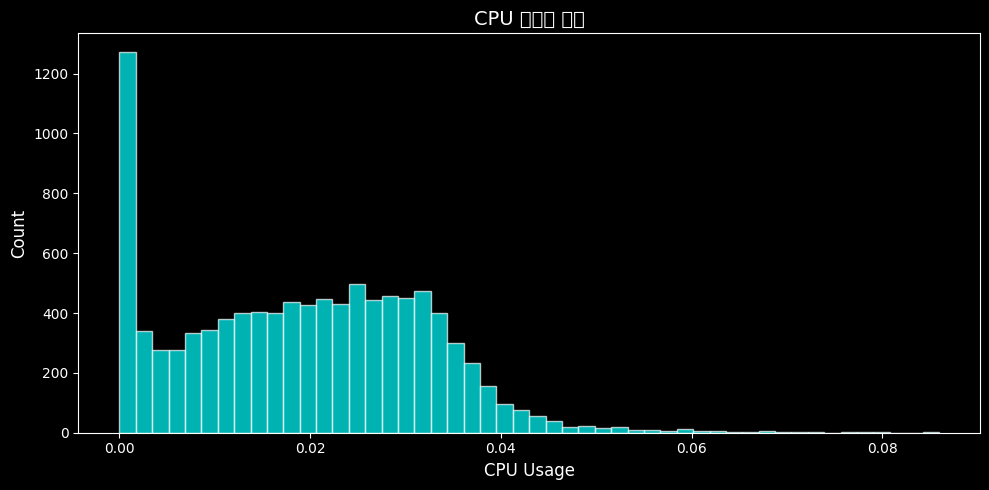

In [10]:
# CPU 사용률 분포
plt.figure(figsize=(10, 5))
plt.hist(df['cpu'], bins=50, color='cyan', edgecolor='white', alpha=0.7)
plt.title('CPU 사용률 분포', fontsize=14, color='white')
plt.xlabel('CPU Usage', fontsize=12, color='white')
plt.ylabel('Count', fontsize=12, color='white')
plt.tight_layout()
plt.show()


/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-377391074.py:30: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

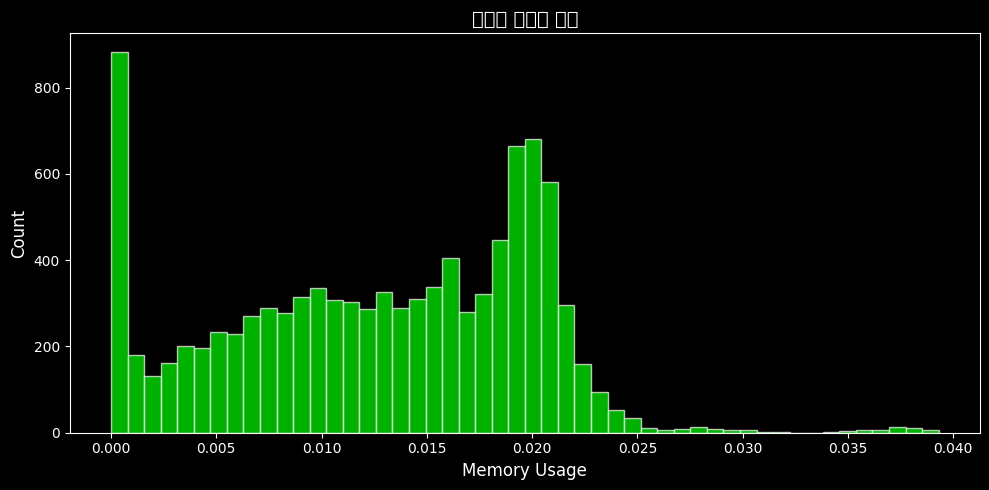

In [11]:
# # 메모리 사용률 분포
# if 'average_usage' in df.columns:
#     mem_col = 'average_usage'
# elif 'avg_mem' in df.columns:
#     mem_col = 'avg_mem'
# else:
#     mem_col = None

# if mem_col:
#     plt.figure(figsize=(12, 6))

#     if isinstance(df[mem_col].iloc[0], dict):
#         mem_values = df[mem_col].apply(lambda x: x.get('memory', 0) if isinstance(x, dict) else 0)
#     else:
#         mem_values = df[mem_col]

#     plt.hist(mem_values, bins=50, color='lime', edgecolor='white', alpha=0.7)
#     plt.title('MEM 사용률 분포', fontsize=14, color='white')
#     plt.xlabel('Memory Usage', fontsize=12, color='white')
#     plt.ylabel('Count', fontsize=12, color='white')
#     plt.tight_layout()
#     plt.show()

# 메모리 사용률 분포
plt.figure(figsize=(10, 5))
plt.hist(df['memory'], bins=50, color='lime', edgecolor='white', alpha=0.7)
plt.title('메모리 사용률 분포', fontsize=14, color='white')
plt.xlabel('Memory Usage', fontsize=12, color='white')
plt.ylabel('Count', fontsize=12, color='white')
plt.tight_layout()
plt.show()

In [ ]:
# # 시간대별 평균 사용량
# if 'start_time' in df.columns:
#     df['time_bucket'] = df['start_time']  # 시간 단위로 변환

#     if isinstance(df['average_usage'].iloc[0], dict):
#         df['cpu'] = df['average_usage'].apply(lambda x: x.get('cpus', 0) if isinstance(x, dict) else 0)
#         df['memory'] = df['average_usage'].apply(lambda x: x.get('memory', 0) if isinstance(x, dict) else 0)

#     time_agg = df.groupby('time_bucket').agg({
#         'cpu': 'mean',
#         'memory': 'mean'
#     }).reset_index()

#     fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#     axes[0].plot(time_agg['time_bucket'], time_agg['cpu'], color='cyan', linewidth=1.5)
#     axes[0].set_title('시간대별 평균 CPU 사용량', fontsize=14, color='white')
#     axes[0].set_xlabel('Time Bucket (hours)', color='white')
#     axes[0].set_ylabel('Avg CPU', color='white')

#     axes[1].plot(time_agg['time_bucket'], time_agg['memory'], color='lime', linewidth=1.5)
#     axes[1].set_title('시간대별 평균 메모리 사용량', fontsize=14, color='white')
#     axes[1].set_xlabel('Time Bucket (hours)', color='white')
#     axes[1].set_ylabel('Avg Memory', color='white')

#     plt.tight_layout()
#     plt.show()

# ===========================================
# 셀 10: 시간대별 평균 (최적화)
# ===========================================
if 'start_time' in df.columns:
    # 시간 단위로 버킷팅
    df['time_bucket'] = df['start_time'] 

    # numpy로 빠르게 집계
    time_agg = df.groupby('time_bucket', as_index=False).agg({
        'cpu': 'mean',
        'memory': 'mean'
    })

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    axes[0].plot(time_agg['time_bucket'], time_agg['cpu'], color='cyan', linewidth=1.5)
    axes[0].set_title('시간대별 평균 CPU', fontsize=14, color='white')
    axes[0].set_ylabel('Avg CPU', color='white')

    axes[1].plot(time_agg['time_bucket'], time_agg['memory'], color='lime', linewidth=1.5)
    axes[1].set_title('시간대별 평균 메모리', fontsize=14, color='white')
    axes[1].set_ylabel('Avg Memory', color='white')

    plt.tight_layout()
    plt.show()

In [ ]:
# print("=" * 50)
# print("EDA 요약")
# print("=" * 50)
# print(f"\n[instance_usage]")
# print(f" - 행 수: {len(df):,}")
# print(f" - 컬럼 수: {len(df.columns)}")
# print(f" - 컬럼: {df.columns.tolist()}")

# if 'cpu' in df.columns:
#     print(f"\n[CPU 사용률]")
#     print(f" - 평균: {df['cpu'].mean():.4f}")
#     print(f" - 최소: {df['cpu'].min():.4f}")
#     print(f" - 최대: {df['cpu'].max():.4f}")

# if 'memory' in df.columns:
#     print(f"\n[메모리 사용률]")
#     print(f" - 평균: {df['memory'].mean():.4f}")
#     print(f" - 최소: {df['memory'].min():.4f}")
#     print(f" - 최대: {df['memory'].max():.4f}")

# ===========================================
print("=" * 50)
print("EDA 요약")
print("=" * 50)
print(f"\n샘플 크기: {len(df):,}행")
print(f"\n[CPU 사용률]")
print(f"  - 평균: {df['cpu'].mean():.4f}")
print(f"  - 최대: {df['cpu'].max():.4f}")
print(f"\n[메모리 사용률]")
print(f"  - 평균: {df['memory'].mean():.4f}")
print(f"  - 최대: {df['memory'].max():.4f}")